In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("customer_churn_data.csv")

In [4]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes
...,...,...,...,...,...,...,...,...,...,...
995,996,42,Male,41,37.14,Month-to-Month,Fiber Optic,1522.74,Yes,Yes
996,997,62,Male,9,80.93,Month-to-Month,NaN,728.37,No,Yes
997,998,51,Female,15,111.72,Month-to-Month,Fiber Optic,1675.80,Yes,Yes
998,999,39,Male,68,65.67,One-Year,NaN,4465.56,No,Yes


In [5]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.2+ KB


In [7]:
df.isna().sum().sum()

np.int64(297)

In [8]:
df["InternetService"] = df["InternetService"].fillna("")

In [9]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [13]:
numeric_columns_data = df.select_dtypes( include= ("number"))

In [16]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [24]:
import matplotlib.pyplot as plt

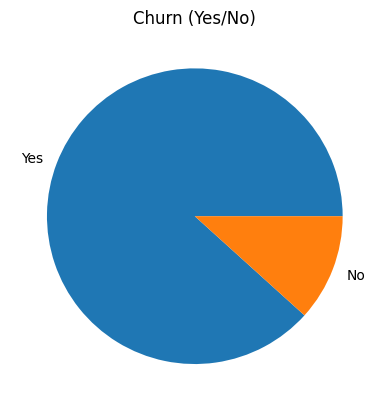

In [26]:
df["Churn"].value_counts().plot(kind="pie")
plt.title("Churn (Yes/No)")
plt.ylabel("")
plt.show()

In [27]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [29]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [30]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [31]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


In [32]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

At lower terms we can see that the montly charges average decreases

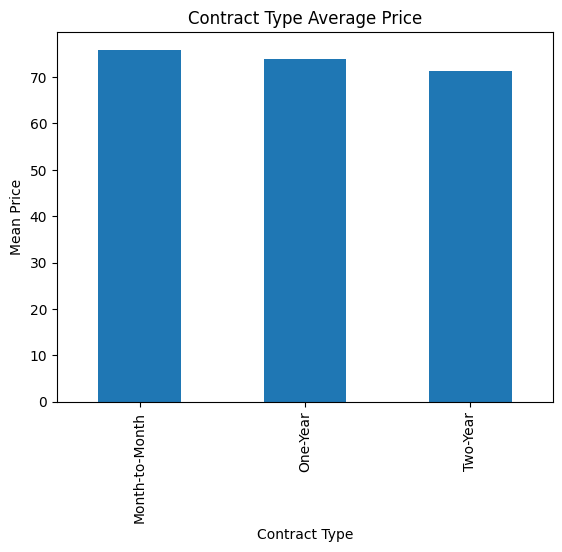

In [36]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Contract Type Average Price")
plt.xlabel("Contract Type")
plt.ylabel("Mean Price")
plt.show()

In [37]:
df.head(2)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.0,Yes,Yes


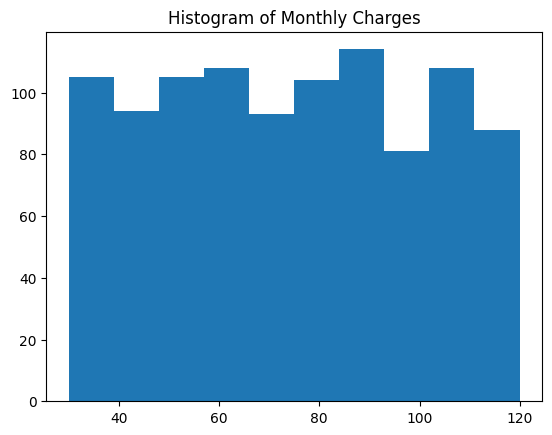

In [39]:
plt.hist(df["MonthlyCharges"])
plt.title("Histogram of Monthly Charges")
plt.show()

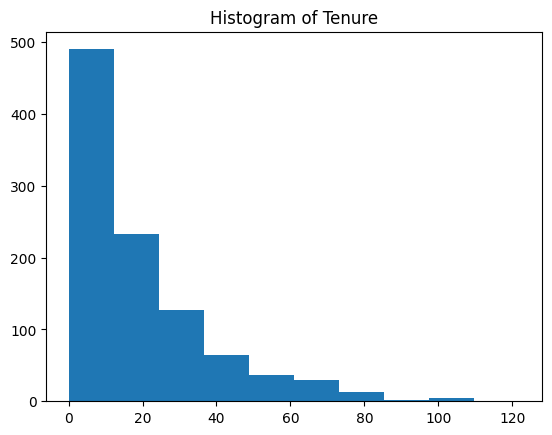

In [40]:
plt.hist(df["Tenure"])
plt.title("Histogram of Tenure")
plt.show()

In [42]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [43]:
df.head(1)

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.4,Yes,Yes


In [44]:
y = df[["Churn"]]
x = df[["Age","Gender","Tenure","MonthlyCharges"]]

In [ ]:
x #1 Female 0 Male

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [46]:
y

,Churn
0,Yes
1,Yes
2,Yes
3,Yes
4,Yes
...,...
995,Yes
996,Yes
997,Yes
998,Yes


In [48]:
x["Gender"] = x["Gender"].apply(lambda x: 1 if x == "Female" else 0)

C:\Users\tejas\AppData\Local\Temp\ipykernel_24264\2979086490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x["Gender"] = x["Gender"].apply(lambda x: 1 if x == "Female" else 0)


In [49]:
x.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [50]:
type(x["Gender"][0])

numpy.int64

In [51]:
y.head(2)

,Churn
0,Yes
1,Yes


In [53]:
y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

C:\Users\tejas\AppData\Local\Temp\ipykernel_24264\3691775968.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)


In [54]:
!pip install sklearn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [55]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/8.9 MB 6.1 MB/s eta 0:00:02
   --------- ------------------------------ 2.1/8.9 MB 5.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.7/8.9 MB 5.9 MB/s eta 0:00:01
   --------------------- ------------------ 4.7/8.9 MB 5.6 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/8.9 MB 5.5 MB/s eta 0:00:01
   ------------------------------ --------- 6.8/8.9 MB 5.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.1/8.9 MB 5.7 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 5.5 MB/s  0:00:01
   ---------------------------------------- 0.0/41.3 MB ? eta -:--:--
   - -------------------------------------- 1.3/41.3 MB 6.7 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/41.3 MB 6.9 MB/s eta 0:00:06
   ---- ----------------------------------- 4.2/41.3 MB 6.8 MB/s eta 0:00:06
   ---- -----------------

In [59]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [60]:
x

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [61]:
y

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


In [63]:
from sklearn.preprocessing import StandardScaler

In [64]:
scaler = StandardScaler()

In [65]:
x_train = scaler.fit_transform(x_train)

In [66]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [67]:
x_test = scaler.fit_transform(x_test)

In [68]:
x_train

array([[ 1.00118541e-01, -1.09997489e+00, -9.50182360e-01,
         2.59174887e-01],
       [-1.84591960e+00, -1.09997489e+00, -1.00434309e+00,
         9.80909354e-01],
       [-3.09573699e-01,  9.09111664e-01, -5.71057229e-01,
        -1.50964363e+00],
       ...,
       [ 7.14656900e-01,  9.09111664e-01,  2.57026529e+00,
         2.42691554e-01],
       [-2.30451885e-03,  9.09111664e-01,  3.76180141e+00,
        -9.04469864e-01],
       [-1.43622736e+00, -1.09997489e+00, -9.50182360e-01,
        -7.07062340e-01]], shape=(800, 4))

In [69]:
x_test

array([[ 8.91041873e-01,  1.00000000e+00,  4.56699750e-01,
        -8.35884071e-01],
       [ 1.09540928e+00, -1.00000000e+00, -8.67778581e-01,
        -2.20437993e-01],
       [-9.48264746e-01,  1.00000000e+00,  5.05754503e-01,
         1.19006933e+00],
       [ 5.84490770e-01,  1.00000000e+00, -1.81012039e-01,
         9.20269237e-01],
       [ 8.91041873e-01, -1.00000000e+00,  7.51028268e-01,
        -3.44583769e-01],
       [ 7.35722647e-02, -1.00000000e+00, -9.65888087e-01,
         3.45576180e-01],
       [-1.45918325e+00, -1.00000000e+00,  6.42617264e-02,
         3.25577013e-01],
       [-9.48264746e-01, -1.00000000e+00,  2.11425985e-01,
        -4.70993601e-01],
       [-7.43897344e-01, -1.00000000e+00, -7.20614322e-01,
        -8.36638757e-01],
       [ 6.86674471e-01,  1.00000000e+00,  5.54809256e-01,
        -4.48730376e-01],
       [-1.25481585e+00,  1.00000000e+00,  7.01973515e-01,
        -6.43816595e-01],
       [-1.30795137e-01,  1.00000000e+00,  4.07644997e-01,
      

In [72]:
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("Accuracy score on model is {}".format(accuracy_score(y_test, predictions)))

In [73]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.linear_model import LogisticRegression

In [75]:
log_model = LogisticRegression()

In [77]:
import warnings
warnings.filterwarnings("ignore")

In [78]:
log_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [79]:
x

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [81]:
y_pred = log_model.predict(x_test)

In [82]:
modelperformance(y_pred)

Accuracy score on model is 0.91


In [83]:
from sklearn.neighbors import KNeighborsClassifier

In [86]:
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    }

In [ ]:
gridkn = GridSearchCV(KNeighborsClassifier(),param_grid,  cv = 5)

In [97]:
gridkn.fit(x_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [91]:
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [92]:
y_pred = gridkn.predict(x_test)

In [93]:
modelperformance(y_pred)

Accuracy score on model is 0.89


In [94]:
from sklearn.svm import SVC

In [95]:
svm = SVC()

In [106]:
!pip install kernel

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 19.4 MB/s  0:00:00

   ------ ---------------------------------  2/13 [pydantic-core]
   --------- ------------------------------  3/13 [idna]
   --------- ------------------------------  3/13 [idna]
   ------------ ---------------------------  4/13 [h11]
   ------------ ---------------------------  4/13 [h11]
   --------------- ------------------------  5/13 [distro]
   --------------------- ------------------  7/13 [annotated-types]
   ------------------------ ---------------  8/13 [pydantic]
   ------------------------ ---------------  8/13 [pydantic]
   ------------------------ ---------------  8/13 [pydantic]
   ------------------------ ---------------  8/13 [pydantic]
   ------------------------ ---------------  8/13 [pydantic]
   ------------------------ ---------------  8/13 [pydantic]
   ------------------------ ---------------  8/13 [pydantic]
   -------

In [111]:
param_grid = {
    "C" : [0.01,0.1,0.5,1],
    "kernel" : ["linear", "rbf", "poly"]
}

In [112]:
gridsvc = GridSearchCV(svm, param_grid,  cv = 5)

In [113]:
gridsvc.fit(x_train, y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [115]:
gridsvc.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [117]:
y_pred = gridsvc.predict(x_test)

In [118]:
modelperformance(y_pred)

Accuracy score on model is 0.915


In [119]:
from sklearn.tree import DecisionTreeClassifier

In [125]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

In [126]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid,  cv = 5)

In [127]:
grid_tree.fit(x_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [129]:
grid_tree.best_params_

{'criterion': 'gini',
 'max_depth': 30,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'splitter': 'random'}

In [130]:
y_pred = grid_tree.predict(x_test)

In [131]:
y_pred

array([1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1])

In [132]:
modelperformance(y_pred)

Accuracy score on model is 0.83


In [134]:
from sklearn.ensemble import RandomForestClassifier 
rfc_model = RandomForestClassifier()

In [135]:
param_grid = {
    "n_estimators": [32, 64, 128, 256],
    "max_features": [2, 3, 4],
    "bootstrap": [True, False]
}

In [136]:
grid_rfc = GridSearchCV(rfc_model, param_grid,  cv = 5)

In [137]:
grid_rfc.fit(x_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [32, 64, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,64


In [138]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64}

In [139]:
y_pred = grid_rfc.predict(x_test)

In [140]:
modelperformance(y_pred)

Accuracy score on model is 0.885


In [141]:
best_model = gridsvc.best_estimator_

In [142]:
joblib.dump(best_model, "model.pkl")

['model.pkl']

In [144]:
x.columns

Index(['Age', 'Gender', 'Tenure', 'MonthlyCharges'], dtype='object')

In [145]:
!pip install streamlit

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   ---------------- ----------------------- 3.7/9.1 MB 19.8 MB/s eta 0:00:01
   -------------------- ------------------- 4.7/9.1 MB 11.9 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/9.1 MB 9.5 MB/s eta 0:00:01
   --------------------------- ------------ 6.3/9.1 MB 8.0 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.1 MB 7.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.1/9.1 MB 5.7 MB/s eta 0:00:01
   --------------------------------- ------ 7.6/9.1 MB 5.3 MB/s eta 0:00:01
   -------------------------------------- - 8.7/9.1 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 5.0 MB/s  0:00:01
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 795.4/795.4 kB 4.9 MB/s  0:00:00
   ---------------------------------------- 0.0/6.9 MB ? eta -:--:--
   ------- --------------------

In [146]:
import streamlit as st